In [2]:
%pip install spacy pandas torch transformers huggingface_hub matplotlib ipympl rdflib sentence_transformers numpy
# optuna and optional dependencies
%pip install optuna scikit-learn plotly 
# Qwen optimization (optional) dependencies
%pip install flash-linear-attention causal-conv1d
# Mistral dependencies
%pip install accelerate


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import optuna
import matplotlib.pyplot as plt
import matplotlib
import optuna.visualization
import optuna.importance
import json
from pathlib import Path
from collections import OrderedDict
from mllms import (
    JSONTuplesPromptTemplate,
    JsonDictPromptTemplate,
    PromptTemplate,
    LLMAddressParsingModel,
    LlamaAddressParsingModel,
    QwenAddressParsingModel,
    MistralAddressParsingModel,
    DeepSeekAddressParsingModel,
    ZeroShot,
    SimilarExamples,
    FixedExamples,
    NERPatternSimilarExamples,
    FallbackExamplesStrategy,
    HybridSimilarExamples,
    FIXED_DEMO_EXAMPLES
)
from utils import compare_preds, format_time
from typing import NamedTuple
from optuna_utils import suggest_partial_permutation, suggest_permutation
import abc
import pandas as pd
import time
import pprint
import textwrap

OPTUNA_DB = "sqlite:///optuna_llms.db"
ESTIMATED_TOTAL_ADDRESSES = 4_228_682 # from compare.ipynb


In [4]:
import torch
available_accelerators = []
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for current_trial in range(torch.cuda.device_count()):
        print(f"  {current_trial}: {torch.cuda.get_device_name(current_trial)}")
        available_accelerators.append(torch.device(f'cuda:{current_trial}'))
elif torch.accelerator.is_available(): # Support other hardware accelators
    available_accelerators.append(torch.accelerator.current_accelerator())
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe


In [5]:
if available_accelerators:
    device = available_accelerators[1]
print(f"Torch version: {torch.__version__}, Device: {device}")

Torch version: 2.10.0+cu128, Device: cuda:1


In [6]:

ROLE_DESCRIPTIONS = OrderedDict([
    ("none", ""),
    (
        "german_archivist_ww2",
        "You are a German archivist handling the digitalization of German documents from "
        "the compensation efforts that followed the Second World War."
    ),
    (
        "archivist_ww2",
        "You are an archivist handling the digitalization of documents from "
        "the compensation efforts that followed the Second World War."
    ),
    (
        "german_archivist",
        "You are a German archivist handling the digitalization of German documents."
    ),
    (
        "archivist",
        "You are an archivist handling the digitalization of documents."
    )
])

TASK_DESCRIPTIONS = OrderedDict([
    ("simple", 
     "Annotate addresses, identifying the respective components of each address."),
    ("current_task", 
     "Your current task consists of annotating addresses "
     "identifying the respective components of each address."),
    ("archival_documents", 
     "Your current task consists of annotating addresses found in archival documents, "
     "identifying the respective components of each address.")
])

TASK_RESTRICTIONS = OrderedDict([
    (
        "loyal_to_text",
        "Remain loyal to the original text."
    ),
    (
        "explicitly_present_information", 
        "Only extract information **explicitly present in the address**."
    ),
    (
        "do_not_infer_missing_components",
        "Do **not infer missing components**."
    ),
    (
        "no_spelling_correction",
        "Do **not correct the spelling** of any word in the address."
    ),
    (
        "if_uncertain_exclude",
        "If uncertain about a component type, exclude it from the output."
    ),
    (
        "separate_neighborhood_and_city",
        "If the address contains a neighborhood joined together with a city "
        "by a dash (e.g., Berlin-Marienfelde), separate them accordingly."
    ),
    (
        "neighborhoods-not-cities",
        "Neighborhoods or boroughs should **not be classified as cities**."
    ),
    (
        "city-takes-precedence",
        "If unsure whether the city name in the address corresponds to the city or to a district, classify it as a city."
    ),
    (
        "district-not-city",
        "If the address contains a clearly identified district "
        "(such as by using the word \"Kreis\") **do not classify it as a city**."
    ),
    (
        "do-not-extract-keywords",
        "Do not extract keywords that identify a component type such "
        "as \"Kreis\", \"Nr.\" or \"Apt.\". "
        "The exception is streets and cities, which typically include "
        "such keywords as part of their name"
    ),
    (
        "do-not-extract-punctuation",
        "Do not extract punctuation around the words such as commas or dashes. "
        "The exception is when the word ends in a period to mark it as an abbreviation"
    ),
    (
        "concentration_camps",
        "Sometimes fields will mention concentration camps. "
        "The names of concentration camps should not be marked as any component."
    ),
    (
        "special_values",
        "Sometimes fields would be used to mark special cases "
        "when an address could not provided, such as when the person is missing. "
        "Do not classify such values as any component."
    ),
    (
        "disambiguation",
        "Sometimes cities will include (often connected by a slash \"/\") a reference to a nearby place (eg. river, city, district or region) "
        "for the purpose of disambiguation. "
        "If this is commonly part of the city name (eg. Frankfurt am Main), "
        "include it as part of the city component. "
        "Otherwise, it it fits another component type, classify it as such. "
        "Finally, if it does not fit any component type include it in the city name anyway."
    )
])

TASK_HINTS = OrderedDict([
    (
        "german_names", 
        "Addresses will often be written in German, meaning country and city names may be in German "
        "rather than the international standard."
    ),
    (
        "hebrew",
        "Addresses in Israel will often have words in Hebrew."
    ),
    (
        "german_phonetic_interpretation",
        "It is likely that the address was written down by a German person "
        "who might have interpreted the phonetics of the words differently. "
        "Therefore, \"J\" might take the place of an \"I\" sound, "
        "\"W\" might take the place of a \"V\" sound, etc."
    ),
    (
        "historical_names",
        "Some addresses might contain historical names of cities, "
        "streets or countries that no longer exist or have changed name."
    ),
    (
        "country_transitions",
        "Some addresses might contain cities that have transitioned to another country since "
        "the filling of the card."
    ),
    (
        "cardinal_direction_streets",
        "Streets in some countries are identified by their cardinal direction and a number, "
        "such as \"West 5th Avenue\"."
    ),
    (
        "abbreviations",
        "Place names in the addresses might be abbreviated."
    ),
    (
        "card_layout_kreis",
        "In some cards, the district keyword (Kreis) is part of the card layout. "
        "You may therefore encounter odd names with that keyword, such as country names."
    )
])

EXAMPLE_TERMS = OrderedDict([
    (
        "burg", 
        "\"burg\" for city"
    ),
    (
        "stadt",
        "\"stadt\" for city"
    ),
    (
        "kreis",
        "\"Kreis\" or its abbreviations \"Krs.\" or \"Kr.\" for district"
    ),
    (
        "regierungsbezirk",
        "\"Regierungsbezirk\" or its abbreviations \"Reg. Bez.\" for district"
    ),
    (
        "straße",
        "\"straße\" or its abbreviation \"str.\" for street"
    ),
    (
        "rechov",
        "\"rechov\" or its abbreviation \"rh.\" for street in Hebrew"
    ),
    (
        "avenue",
        "\"avenue\" or its abbreviation \"ave.\" for street"
    )
])

OUTPUT_FORMATS = OrderedDict([
    ("json_object", (
        "Format the output as a JSON object with the component types as keys.",
        JsonDictPromptTemplate
        )
    ),
    ("json_tuples", (
        "Format the output as a JSON list of [component, type] tuples.",
        JSONTuplesPromptTemplate
        )
    )
])

ENTITIES = [
    "HouseNumber",
    "StreetName",
    "Neighborhood",
    "City",
    "District",
    "State",
    "Region",
    "Country",
    "Other"
]

REQUIRED_ENTITIES = [
    "HouseNumber",
    "StreetName",
    "City",
    "Country"
]

OPTIONAL_ENTITIES = [entity for entity in ENTITIES if entity not in REQUIRED_ENTITIES]

PROMPT_SECTIONS = [
    "restrictions",
    "hints",
    "example_terms"
]

class PromptBuilder(abc.ABC):
    def __init__(
            self,
            role_description, 
            task_description,
            section_order,
            entities, 
            restrictions, 
            hints, 
            example_terms,
            terms_may_be_suffix,
            output_format
        ):
        self.role_description = role_description
        self.task_description = task_description
        self.section_order = section_order
        self.entities = entities
        self.restrictions = restrictions
        self.hints = hints
        self.example_terms = example_terms
        self.terms_may_be_suffix = terms_may_be_suffix
        self.output_format = output_format
        self.build_buffer : list[str] = []

    @abc.abstractmethod
    def _append_restrictions(self):
        raise NotImplementedError()
    
    @abc.abstractmethod
    def _append_hints(self):
        raise NotImplementedError()
    
    @abc.abstractmethod
    def _append_example_terms(self):
        raise NotImplementedError()

    def _append_item_list(self, keys : list[str], dictionary : dict[str, str]):
        for key in keys:
            self.build_buffer.append("- " + dictionary[key] + "\n")
    
    def _append_sections(self):
        for section in PROMPT_SECTIONS:
            if section not in self.section_order:
                raise ValueError(f"Section order must include all sections. Missing {section}.")
        for section in self.section_order:
            if section == "restrictions" and self.restrictions:
                self._append_restrictions()
            elif section == "hints" and self.hints:
                self._append_hints()
            elif section == "example_terms" and self.example_terms:
                self._append_example_terms()
            elif section not in PROMPT_SECTIONS:
                raise ValueError(f"Unknown section {section}.")

    @abc.abstractmethod
    def build(self) -> PromptTemplate:
        raise NotImplementedError()

class MarkdownPromptBuilder(PromptBuilder):
    def _append_restrictions(self):
        self.build_buffer.append("## Rules:\n\n")
        self._append_item_list(self.restrictions, TASK_RESTRICTIONS)
        self.build_buffer.append("\n")

    def _append_hints(self):
        self.build_buffer.append("## Hints:\n\n")
        self.build_buffer.append("When interpreting the addresses, take into consideration:\n")
        self._append_item_list(self.hints, TASK_HINTS)
        self.build_buffer.append("\n")

    def _append_example_terms(self):
        self.build_buffer.append("## Example Terms:\n\n")
        self.build_buffer.append("The addresses often include terms such as:\n")
        self._append_item_list(self.example_terms, EXAMPLE_TERMS)
        if self.terms_may_be_suffix:
            self.build_buffer.append("Some of these terms may occur as a suffix to another word.\n")
        self.build_buffer.append("\n")

    def build(self) -> PromptTemplate:
        self.build_buffer = []
        if self.role_description != "none":
            self.build_buffer.append("# Role\n\n")
            self.build_buffer.append(ROLE_DESCRIPTIONS[self.role_description])
            self.build_buffer.append("\n\n")
        self.build_buffer.append("# Task\n\n")
        self.build_buffer.append(TASK_DESCRIPTIONS[self.task_description])
        self.build_buffer.append(" Consider the component types: ")
        self.build_buffer.append(", ".join(self.entities))
        self.build_buffer.append(".\n\n")
        self._append_sections()
        self.build_buffer.append(OUTPUT_FORMATS[self.output_format][0])
        self.build_buffer.append("\n")
        self.build_buffer.append("%(examples)s\n")
        self.build_buffer.append("Now annotate the following address:\n%(address)s")
        prompt_template = "".join(self.build_buffer)
        example_prefix = "# Examples\n\n"
        prompt_class = OUTPUT_FORMATS[self.output_format][1]
        return prompt_class(
            template=prompt_template,
            examples_prefix=example_prefix
        )

class PlainPromptBuilder(PromptBuilder):
    def _append_restrictions(self):
        self.build_buffer.append("It is essential that while solving the task you stick to the following rules:\n")
        self._append_item_list(self.restrictions, TASK_RESTRICTIONS)
        self.build_buffer.append("\n")

    def _append_hints(self):
        self.build_buffer.append("When interpreting the addresses, take into consideration:\n")
        self._append_item_list(self.hints, TASK_HINTS)
        self.build_buffer.append("\n")

    def _append_example_terms(self):
        self.build_buffer.append("The addresses often include terms such as:\n")
        self._append_item_list(self.example_terms, EXAMPLE_TERMS)
        if self.terms_may_be_suffix:
            self.build_buffer.append("Some of these terms may occur as a suffix to another word.\n")
        self.build_buffer.append("\n")

    def build(self) -> PromptTemplate:
        self.build_buffer = []
        if self.role_description != "none":
            self.build_buffer.append(ROLE_DESCRIPTIONS[self.role_description])
            self.build_buffer.append(" ")
        self.build_buffer.append(TASK_DESCRIPTIONS[self.task_description])
        self.build_buffer.append(" Consider the component types: ")
        self.build_buffer.append(", ".join(self.entities))
        self.build_buffer.append(".\n\n")
        self._append_sections()
        self.build_buffer.append(OUTPUT_FORMATS[self.output_format][0])
        self.build_buffer.append("\n")
        self.build_buffer.append("%(examples)s\n")
        self.build_buffer.append("Now annotate the following address:\n%(address)s")
        prompt_template = "".join(self.build_buffer)
        example_prefix = "Consider the following examples:\n"
        prompt_class = OUTPUT_FORMATS[self.output_format][1]
        return prompt_class(
            template=prompt_template,
            examples_prefix=example_prefix
        )
    
PROMPT_FORMATS = OrderedDict([
    ("plain", PlainPromptBuilder),
    ("markdown", MarkdownPromptBuilder)
])

def suggest_prompt(trial : optuna.Trial, entities_to_predict) -> PromptTemplate:
    prompt_format = trial.suggest_categorical("prompt_format", ["plain", "markdown"])
    role_description = trial.suggest_categorical("prompt_role_description", list(ROLE_DESCRIPTIONS.keys()))
    task_description = trial.suggest_categorical("prompt_task_description", list(TASK_DESCRIPTIONS.keys()))
    restrictions = suggest_partial_permutation(trial, "prompt_restrictions", list(TASK_RESTRICTIONS.keys()))
    hints = suggest_partial_permutation(trial, "prompt_hints", list(TASK_HINTS.keys()))
    example_terms = suggest_partial_permutation(trial, "prompt_example_terms", list(EXAMPLE_TERMS.keys()))
    section_order = suggest_permutation(trial, "prompt_section_order", PROMPT_SECTIONS)
    if len(example_terms) > 0:
        terms_may_be_suffix = trial.suggest_categorical("prompt_example_terms_may_be_suffix", [True, False])
    else: terms_may_be_suffix = False
    output_format = trial.suggest_categorical("output_format", list(OUTPUT_FORMATS.keys()))
    prompt_builder = PROMPT_FORMATS[prompt_format](
        role_description, task_description, section_order, entities_to_predict, restrictions,
        hints, example_terms, terms_may_be_suffix, output_format
    )
    return prompt_builder.build()

In [7]:
def get_random_prompts(n = 1, seed=None):
    sampler = optuna.samplers.RandomSampler(seed)
    study = optuna.create_study(sampler=sampler)
    return [
        suggest_prompt(study.ask(), ENTITIES) for _ in range(n)
    ]

for current_trial, prompt in enumerate(get_random_prompts(n=20)):
    print(f"Prompt {current_trial}")
    print(prompt.template)
    print("\n")

[I 2026-03-25 07:23:04,381] A new study created in memory with name: no-name-ba046f07-e0df-4c38-9fb5-9aef733a3c94


Prompt 0
# Role

You are an archivist handling the digitalization of documents from the compensation efforts that followed the Second World War.

# Task

Your current task consists of annotating addresses found in archival documents, identifying the respective components of each address. Consider the component types: HouseNumber, StreetName, Neighborhood, City, District, State, Region, Country, Other.

## Rules:

- Only extract information **explicitly present in the address**.
- Do **not correct the spelling** of any word in the address.
- Do **not infer missing components**.
- Sometimes fields would be used to mark special cases when an address could not provided, such as when the person is missing. Do not classify such values as any component.
- Remain loyal to the original text.
- If the address contains a neighborhood joined together with a city by a dash (e.g., Berlin-Marienfelde), separate them accordingly.
- If unsure whether the city name in the address corresponds to the city

In [8]:
csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)

In [9]:
def suggest_example_strategy(trial : optuna.Trial, entities_to_predict):
    example_strategy = trial.suggest_categorical("example_strategy", [
        "zero_shot",
        "similar_semantic_embeddings",
        "fixed_examples",
        "ner_pattern_matching",
        "hybrid_embeddings_ner",
        #"embeddings_fallback_fixed"
    ])
    def suggest_nshots():
        return trial.suggest_int("number_of_examples", 0, 15)

    def suggest_cosine_similarity_threshold():
        return trial.suggest_float("similar_semantic_embeddings_threshold", -1.0, 1.0, step=0.05)
    
    def suggest_embedding_model():
        return trial.suggest_categorical("similar_semantic_embeddings_embedding_model", [
            "multi-qa-mpnet-base-dot-v1",
            "all-MiniLM-L6-v2",
            "multi-qa-distilbert-cos-v1"
        ])
    
    def suggest_fixed_examples():
        example_keys = [str(i) for i in range(len(FIXED_DEMO_EXAMPLES))]
        example_keys = suggest_partial_permutation(trial, "fixed_examples", example_keys)
        return [FIXED_DEMO_EXAMPLES[int(key)] for key in example_keys]
        
    if example_strategy == "zero_shot":
        trial.set_user_attr("number_of_examples", 0)
        return ZeroShot()
    if example_strategy == "similar_semantic_embeddings":
        threshold = suggest_cosine_similarity_threshold()
        embedding_model = suggest_embedding_model()
        n_shots = suggest_nshots()
        trial.set_user_attr("number_of_examples", n_shots)
        return SimilarExamples(
            num_examples=n_shots,
            similarity_threshold=threshold,
            embedding_model=embedding_model,
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            labels_to_include=entities_to_predict
        )
    elif example_strategy == "fixed_examples":
        fixed_examples = suggest_fixed_examples()
        trial.set_user_attr("number_of_examples", len(fixed_examples))
        return FixedExamples(fixed_examples, labels_to_include=entities_to_predict)
    elif example_strategy == "ner_pattern_matching":
        n_shots = suggest_nshots()
        trial.set_user_attr("number_of_examples", n_shots)
        return NERPatternSimilarExamples(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=n_shots,
            labels_to_include=entities_to_predict
        )
    elif example_strategy == "hybrid_embeddings_ner":
        threshold = suggest_cosine_similarity_threshold()
        embedding_model = suggest_embedding_model()
        n_shots = suggest_nshots()
        trial.set_user_attr("number_of_examples", n_shots)
        return HybridSimilarExamples(
            embedding_strategy=SimilarExamples(
                num_examples=n_shots,
                similarity_threshold=threshold,
                embedding_model=embedding_model,
                example_addresses=bzkopen_train["FullAddress"],
                example_labels=bzkopen_train,
                labels_to_include=entities_to_predict
            ),
            pattern_strategy=NERPatternSimilarExamples(
                example_addresses=bzkopen_train["FullAddress"],
                example_labels=bzkopen_train,
                num_examples=n_shots,
                labels_to_include=entities_to_predict
            ),
            num_examples=n_shots,
            pool_size=n_shots
        )
    # TODO why exclude all embedding retrieved examples based on average instead of each example individually?
    #elif example_strategy == "embeddings_fallback_fixed":
    #    threshold = suggest_cosine_similarity_threshold()
    #    embedding_model = suggest_embedding_model()
    #    n_shots = suggest_nshots()
    #    fixed_examples = suggest_fixed_examples()
    #    trial.set_user_attr("number_of_examples", n_shots)
    #    return FallbackExamplesStrategy(
    #        primary_strategy=SimilarExamples(
    #            num_examples=n_shots,
    #            embedding_model=embedding_model,
    #            example_addresses=bzkopen_train["FullAddress"],
    #            example_labels=bzkopen_train,
    #            labels_to_include=entities_to_predict
    #        ),
    #        labels_to_include=entities_to_predict,
    #        demo_examples=fixed_examples
    #    )
    else:
        raise NotImplementedError(f"Example strategy {example_strategy} not implemented.")


class ScoreTuple(NamedTuple):
    f1 : float
    precision : float
    country_city_f1 : float
    n_entities : int
    all_entities_f1 : float
    rate : float

DIRECTIONS = [
    "maximize",
    "maximize",
    "maximize",
    "maximize",
    "maximize",
    "maximize"
]

class LLMModelObjective:
    def __init__(self, model_names : str | list[str], model_class, study_name : str = None):
        if isinstance(model_names, str):
            model_names = [model_names]
        self.model_names = model_names
        self.model_class = model_class
        self.study_name = study_name or model_names[0]
        self.preds_callback = None
        self.dataset = bzkopen_val

    def __call__(self, trial : optuna.Trial):
        entities = suggest_partial_permutation(trial, "prompt_extra_entities", OPTIONAL_ENTITIES)
        entities = REQUIRED_ENTITIES + entities
        entities = [entity for entity in ENTITIES if entity in entities] # Recover original order
        entities_except_other = [entity for entity in entities if entity != "Other"]
        prompt = suggest_prompt(trial, entities)
        if len(self.model_names) == 1:
            model_name = self.model_names[0]
        else:
            model_name = trial.suggest_categorical("model", self.model_names)
        trial.set_user_attr("entities", entities)
        trial.set_user_attr("n_entities", len(entities))
        trial.set_user_attr("prompt_template", prompt.template)
        trial.set_user_attr("prompt_class", prompt.__class__.__name__)
        example_strategy = suggest_example_strategy(trial, entities_except_other)
        model = self.model_class(
            model_name=model_name,
            prompt=prompt,
            example_strategy=example_strategy,
            device=device
        )
        start = time.monotonic()
        preds = model.parse_addresses(bzkopen_val["FullAddress"])
        end = time.monotonic()
        if self.preds_callback is not None:
            self.preds_callback(preds)
        preds = pd.DataFrame(preds)
        results = {}
        results["required"] = compare_preds(preds=preds, labels=bzkopen_val, target_columns=REQUIRED_ENTITIES)
        results["country_city"] = compare_preds(preds=preds, labels=bzkopen_val, target_columns=["City", "Country"])
        results["all_entities"] = compare_preds(preds=preds, labels=bzkopen_val, target_columns=entities_except_other)
        
        for key, subdict in results.items():
            for metric, value in subdict.items():
                trial.set_user_attr(f"{key}_{metric}", value)

        deltatime = end - start
        rate = len(bzkopen_val) / deltatime
        trial.set_user_attr("deltatime", deltatime)
        trial.set_user_attr("rate", rate)
        trial.set_user_attr("estimated_total_time", format_time(ESTIMATED_TOTAL_ADDRESSES / rate))
        

        errors = int(preds["error"].notna().sum()) if "error" in preds.columns else 0
        trial.set_user_attr("errors", errors)
        trial.set_user_attr("error_rate", errors / len(preds))

        return ScoreTuple(
            f1=results["required"]["f1"], 
            precision=results["required"]["precision"], 
            country_city_f1=results["country_city"]["f1"],
            n_entities=len(entities),
            all_entities_f1=results["all_entities"]["f1"],
            rate=rate
        )




In [10]:

def print_trial_info(study : optuna.Study, trial : optuna.Trial):
    print(f"Trial {trial.number}")
    pprint.pprint(ScoreTuple(*trial.values)._asdict(), sort_dicts=False)
    print("Params:")
    pprint.pprint(trial.params)
    user_attrs = trial.user_attrs.copy()
    prompt_template = user_attrs.pop("prompt_template")
    print(f"User attrs:")
    pprint.pprint(user_attrs)
    print(f"Prompt template:\n{prompt_template}\n")


def run_study_up_to(study : optuna.Study, objective, stop_trial : int, **kwargs):
    n_trials_to_run = stop_trial - len(study.trials)
    # default args:
    kwargs["gc_after_trial"] = kwargs.get("gc_after_trial", True)
    kwargs["callbacks"] = kwargs.get("callbacks", [print_trial_info])
    if n_trials_to_run > 0:
        study.optimize(objective, n_trials=n_trials_to_run, **kwargs)
    else:
        print(f"Study already has {len(study.trials)} trials, which is greater than or equal to the requested {stop_trial} trials. No optimization will be run.")

models_to_study = [
    LLMModelObjective("Qwen/Qwen3.5-9B", 
                      QwenAddressParsingModel, study_name="Qwen3.5-9B"),
    LLMModelObjective("meta-llama/Meta-Llama-3-8B-Instruct", 
                      LlamaAddressParsingModel, study_name="Llama-3-8B"),
    LLMModelObjective("mistralai/Ministral-3-8B-Instruct-2512", 
                      MistralAddressParsingModel, study_name="Mistral-3-8B-Instruct"),
    LLMModelObjective("mistralai/Ministral-3-8B-Reasoning-2512", 
                      MistralAddressParsingModel, study_name="Mistral-3-8B-Reasoning"),
    LLMModelObjective("deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
                      DeepSeekAddressParsingModel, study_name="DeepSeek-R1-Llama-8B"),
    LLMModelObjective("deepseek-ai/DeepSeek-R1-0528-Qwen3-8B",
                      DeepSeekAddressParsingModel, study_name="DeepSeek-R1-Qwen3-8B")
                      
]

studies = [
    optuna.create_study(
        storage = OPTUNA_DB,
        study_name=model.study_name,
        load_if_exists=True,
        directions=DIRECTIONS
    ) for model in models_to_study
]

def run_all_up_to(studies, models_to_study, n_trials = 100, rotate = 50, **kwargs):
    current_trial = 0
    while current_trial < n_trials:
        next_trial = n_trials if rotate is None else min(current_trial + rotate, n_trials)
        for study, model in zip(studies, models_to_study):
            print(f"Running study {study.study_name} up to trial {next_trial}")
            run_study_up_to(study, model, stop_trial=next_trial, **kwargs)
        current_trial = next_trial
    print("\nAll studies completed.\n")
    for study in studies:
        best_trials = study.best_trials.copy()
        best_trials.sort(key=lambda trial: trial.values, reverse=True)
        if best_trials:
            print(f"Best trials for study {study.study_name}:")
            for best_trial in best_trials:
                print_trial_info(study, best_trial)
        else:
            print(f"No trials found for study {study.study_name}.")
        print("\n\n")



[I 2026-03-25 07:23:04,735] Using an existing study with name 'Qwen3.5-9B' instead of creating a new one.
[I 2026-03-25 07:23:04,759] Using an existing study with name 'Llama-3-8B' instead of creating a new one.
[I 2026-03-25 07:23:04,781] Using an existing study with name 'Mistral-3-8B-Instruct' instead of creating a new one.
[I 2026-03-25 07:23:04,803] Using an existing study with name 'Mistral-3-8B-Reasoning' instead of creating a new one.
[I 2026-03-25 07:23:04,823] Using an existing study with name 'DeepSeek-R1-Llama-8B' instead of creating a new one.
[I 2026-03-25 07:23:04,845] Using an existing study with name 'DeepSeek-R1-Qwen3-8B' instead of creating a new one.


In [11]:
#Run each model once to make sure everything is set up correctly
run_all_up_to(studies, models_to_study, n_trials=1)

Running study Qwen3.5-9B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Llama-3-8B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Reasoning up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Llama-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Qwen3-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.

All studies completed.


In [12]:
# Run all studies up to 10 trials to get a sense of expectable performance and time requirements
run_all_up_to(studies, models_to_study, n_trials=10, rotate=1)

Running study Qwen3.5-9B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Llama-3-8B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Reasoning up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Llama-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Qwen3-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Qwen3.5-9B

Study already has 100 trials, which is greater than or equal to the requested 3 trials. No optimization will be run.
Running study Llama-3-8B up to trial 3
Study already has 100 trials, which is greater than or equal to the requested 3 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 3
Study already has 100 trials, which is greater than or equal to the requested 3 trials. No optimization will be run.
Running study Mistral-3-8B-Reasoning up to trial 3
Study already has 10 trials, which is greater than or equal to the requested 3 trials. No optimization will be run.
Running study DeepSeek-R1-Llama-8B up to trial 3
Study already has 10 trials, which is greater than or equal to the requested 3 trials. No optimization will be run.
Running study DeepSeek-R1-Qwen3-8B up to trial 3
Study already has 10 trials, which is greater than or equal to the requested 3 trials. No optimization will be run.
Running study Qwen3.5-9B up to trial 4
Study already has 100 tr

In [13]:
def get_top_studies(studies, models_to_study, top_k=3):
    # Select the best 3 studies and models to run up to 100 trials
    studies_scored = [
        (
            study,
            objective,
            max(trial.values for trial in study.best_trials)
        ) for study, objective in zip(studies, models_to_study) if study.best_trials
    ]

    studies_scored.sort(key=lambda x: tuple(x[2]), reverse=True) # Sort by score tuple in descending order
    top_study_tuples = studies_scored[:top_k]
    top_studies = [tup[0] for tup in top_study_tuples]
    top_objectives = [tup[1] for tup in top_study_tuples]

    print("Best studies:")
    for study in top_studies:
        print(f"Study {study.study_name} - Number of trials: {len(study.trials)}")
        best_trial = max(study.best_trials, key=lambda trial: tuple(trial.values))
        print_trial_info(study, best_trial)
        print("\n\n")
    return top_studies, top_objectives
top_studies, top_objectives = get_top_studies(studies, models_to_study, top_k=3)


Best studies:
Study Qwen3.5-9B - Number of trials: 100
Trial 38
{'f1': 0.912,
 'precision': 0.9076433121019108,
 'country_city_f1': 0.9287598944591028,
 'n_entities': 6.0,
 'all_entities_f1': 0.8892215568862275,
 'rate': 4.170326593219914}
Params:
{'example_strategy': 'hybrid_embeddings_ner',
 'number_of_examples': 15,
 'output_format': 'json_object',
 'prompt_example_terms_avenue_include': False,
 'prompt_example_terms_burg_include': False,
 'prompt_example_terms_kreis_include': False,
 'prompt_example_terms_may_be_suffix': True,
 'prompt_example_terms_rechov_include': False,
 'prompt_example_terms_regierungsbezirk_include': False,
 'prompt_example_terms_stadt_include': False,
 'prompt_example_terms_straße_include': True,
 'prompt_extra_entities_District_include': False,
 'prompt_extra_entities_Neighborhood_include': True,
 'prompt_extra_entities_Neighborhood_sortkey': 0,
 'prompt_extra_entities_Other_include': True,
 'prompt_extra_entities_Region_include': False,
 'prompt_extra_entit

In [14]:
run_all_up_to(top_studies, top_objectives, n_trials=100)

Running study Qwen3.5-9B up to trial 50
Study already has 100 trials, which is greater than or equal to the requested 50 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 50
Study already has 100 trials, which is greater than or equal to the requested 50 trials. No optimization will be run.
Running study Llama-3-8B up to trial 50
Study already has 100 trials, which is greater than or equal to the requested 50 trials. No optimization will be run.
Running study Qwen3.5-9B up to trial 100
Study already has 100 trials, which is greater than or equal to the requested 100 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 100
Study already has 100 trials, which is greater than or equal to the requested 100 trials. No optimization will be run.
Running study Llama-3-8B up to trial 100
Study already has 100 trials, which is greater than or equal to the requested 100 trials. No optimization will be run.

All studies completed.


In [15]:
def param_box_plot(study_df : pd.DataFrame, *, target = ("values", 0), param_name : str | None = None, user_attr : str | None = None):
    assert (param_name is not None) != (user_attr is not None), "Exactly one of param_name or user_attr must be provided."
    df = study_df
    df = df[df["state"] == "COMPLETE"]
    col_type = "params" if param_name is not None else "user_attrs"
    col_name = param_name if param_name is not None else user_attr
    df = df[df[(col_type, col_name)].notna()]
    df = df[[target, (col_type, col_name)]].pivot(columns=[(col_type, col_name)], values=target)
    return df.plot.box(
        title=f"Distribution of objective value by {col_name}",
        vert=False,
        grid=True,
        figsize=(10, max(6, len(df.columns) * 0.05))
    )

def param_scatter_plot(study_df : pd.DataFrame, *, target = ("values", 0), param_name : str | None = None, user_attr : str | None = None, **kwargs):
    assert (param_name is not None) != (user_attr is not None), "Exactly one of param_name or user_attr must be provided."
    df = study_df
    df = df[df["state"] == "COMPLETE"]
    col_type = "params" if param_name is not None else "user_attrs"
    col_name = param_name if param_name is not None else user_attr
    df = df[df[(col_type, col_name)].notna()]
    kwargs.setdefault("title", f"Distribution of objective value by {col_name}")
    return df.plot.scatter(
        x=(col_type, col_name),
        y=target,
        **kwargs
    )

def param_list_box_plot(study_df : pd.DataFrame, list_key : str, *, target = ("values", 0)):
    list_include_params = [
        param for param in study_df.columns 
        if param[0] == "params" and param[1].startswith(list_key + "_") and param[1].endswith("_include")
    ]
    list_include_params.sort(reverse=True) # Sort in reverse to have "no item" columns appear before "item" columns in the plot
    df = study_df[study_df["state"] == "COMPLETE"]
    selected = OrderedDict()

    for col in list_include_params:
        mask = df[col].eq(True)
        neg_mask = df[col].eq(False)
        if mask.any():
            name = col[1][len(list_key) + 1 : -len("_include")]
            selected["no " + name] = df.loc[neg_mask, target].reset_index(drop=True)
            selected[name] = df.loc[mask, target].reset_index(drop=True)
    if not selected:
        raise ValueError(f"No trials found with any '{list_key}_*_include' set to True.")

    plot_df = pd.DataFrame(selected)
    ax, box_lines = plot_df.plot.box(
        title=f"Distribution of objective value by {list_key} items (include=True)",
        vert=False,
        grid=True,
        figsize=(10, max(6, len(df.columns) * 0.05)),
        medianprops={"color": "blue"},
        return_type="both"
    )
    for i, colname in enumerate(plot_df.columns):
        color = "red" if colname.startswith("no ") else "green"
        box_lines["boxes"][i].set_color(color)
        box_lines["whiskers"][2*i].set_color(color)
        box_lines["whiskers"][2*i + 1].set_color(color)
        box_lines["caps"][2*i].set_color(color)
        box_lines["caps"][2*i + 1].set_color(color)
    return ax

def show_prompt_items(dict_to_show : dict, items : list[str]):
    for item in items:
        print(item)
        print(textwrap.fill(dict_to_show[item], initial_indent="  ", subsequent_indent="  "))
        print()

top_studies, top_objectives = get_top_studies(studies, models_to_study, top_k=3)


Best studies:
Study Qwen3.5-9B - Number of trials: 100
Trial 38
{'f1': 0.912,
 'precision': 0.9076433121019108,
 'country_city_f1': 0.9287598944591028,
 'n_entities': 6.0,
 'all_entities_f1': 0.8892215568862275,
 'rate': 4.170326593219914}
Params:
{'example_strategy': 'hybrid_embeddings_ner',
 'number_of_examples': 15,
 'output_format': 'json_object',
 'prompt_example_terms_avenue_include': False,
 'prompt_example_terms_burg_include': False,
 'prompt_example_terms_kreis_include': False,
 'prompt_example_terms_may_be_suffix': True,
 'prompt_example_terms_rechov_include': False,
 'prompt_example_terms_regierungsbezirk_include': False,
 'prompt_example_terms_stadt_include': False,
 'prompt_example_terms_straße_include': True,
 'prompt_extra_entities_District_include': False,
 'prompt_extra_entities_Neighborhood_include': True,
 'prompt_extra_entities_Neighborhood_sortkey': 0,
 'prompt_extra_entities_Other_include': True,
 'prompt_extra_entities_Region_include': False,
 'prompt_extra_entit

In [16]:

top_study, top_objective = top_studies[0], top_objectives[0]
best_trial = max(top_study.best_trials, key=lambda trial: tuple(trial.values))


In [28]:
best_trial_preds = None
preds_file = Path(f"best_trial_{top_study.study_name}_preds.json")
def store_preds(preds):
    with open(preds_file, "w") as f:
        json.dump(preds, f)
    print(f"Predictions stored to {preds_file}")

if not preds_file.exists():
    top_objective.preds_callback = store_preds
    top_objective(best_trial)
    top_objective.preds_callback = None

with open(preds_file, "r") as f:
    best_trial_preds = json.load(f)
best_trial_preds = pd.DataFrame(best_trial_preds)
entities = best_trial.user_attrs["entities"]
entities_except_other = [entity for entity in entities if entity != "Other"]
best_trial_statistics = pd.DataFrame(
    OrderedDict([
        ("required_entities", compare_preds(preds=best_trial_preds, labels=bzkopen_val, target_columns=REQUIRED_ENTITIES)),
        ("included_entities", compare_preds(preds=best_trial_preds, labels=bzkopen_val, target_columns=entities_except_other))
    ] + [
        (entity, compare_preds(preds=best_trial_preds, labels=bzkopen_val, target_columns=[entity])) for entity in entities_except_other
    ])).transpose()
best_trial_statistics[["f1", "precision", "recall", "accuracy"]].style.format("{:.2f}")

,f1,precision,recall,accuracy
required_entities,0.91,0.91,0.92,0.95
included_entities,0.89,0.88,0.90,0.94
HouseNumber,0.88,0.87,0.88,0.95
StreetName,0.90,0.89,0.90,0.95
Neighborhood,0.56,0.50,0.63,0.88
City,0.92,0.91,0.92,0.91
Country,0.98,0.98,0.98,0.99


In [36]:
prediction_errors = best_trial_preds.reset_index(names=["Row"]).melt(
    id_vars=["Row"],
    value_vars=entities_except_other,
    var_name="Entity",
    value_name="PredictedValue"
).merge(
    bzkopen_val.reset_index(names=["Row"]).melt(
        id_vars=["Row", "FullAddress"],
        value_vars=entities_except_other,
        var_name="Entity",
        value_name="TrueValue"
    ),
    on=["Row", "Entity"]
)
prediction_errors = prediction_errors[prediction_errors["PredictedValue"] != prediction_errors["TrueValue"]]
prediction_errors["PredictedValue"] = prediction_errors["PredictedValue"].str.replace(" ", "␣", regex=False)
prediction_errors["TrueValue"] = prediction_errors["TrueValue"].str.replace(" ", "␣", regex=False)
prediction_errors.dropna(subset=["PredictedValue", "TrueValue"], how="all", inplace=True)
prediction_errors.set_index(["Row", "Entity"], inplace=True)
prediction_errors = prediction_errors[["FullAddress", "TrueValue", "PredictedValue"]]
prediction_errors

,,FullAddress,TrueValue,PredictedValue
Row,Entity,,,
0,HouseNumber,"Regensburg, Königstr. 2/I",2/I,2
23,HouseNumber,20 Orchideenstieg 9.,NaN,9
31,HouseNumber,"Jaffo, Rh. 35/2",2,35/2
33,HouseNumber,"Jaffo, Str. 344, No. 6",N␣6,No.␣6
49,HouseNumber,Hohenrode Haus-Nr. 29,Haus-Nr.␣29,29
112,HouseNumber,"3/51 Roscoe Street, Bondi Sydney/Austr.",51,3/51
136,HouseNumber,"Kinzenbach, Waldstr. 55 b/Wetzlar",55␣b,55
147,HouseNumber,2114-79 St. Jackson Heights. N.Y. USA,2114,2114-79
31,StreetName,"Jaffo, Rh. 35/2",Rh.␣35,Rh.


In [19]:


study_df = top_study.trials_dataframe(multi_index=True)
%matplotlib inline


# Example Strategy

**Zero Shot** Included as baseline

**Similar semantic embeddings** Uses embedding models and consine similarity. 3 different models tested.

**Fixed Examples** Fixed examples are chosen by optuna from a pool of 7 examples selected manually by Amel.

**NER Pattern Matching** Uses a NER model trained on BZK Open training set (which only reached 75% accuracy) to determine the address pattern similarity.

**Hybrid matching** Combines embedding similarity with NER similarity

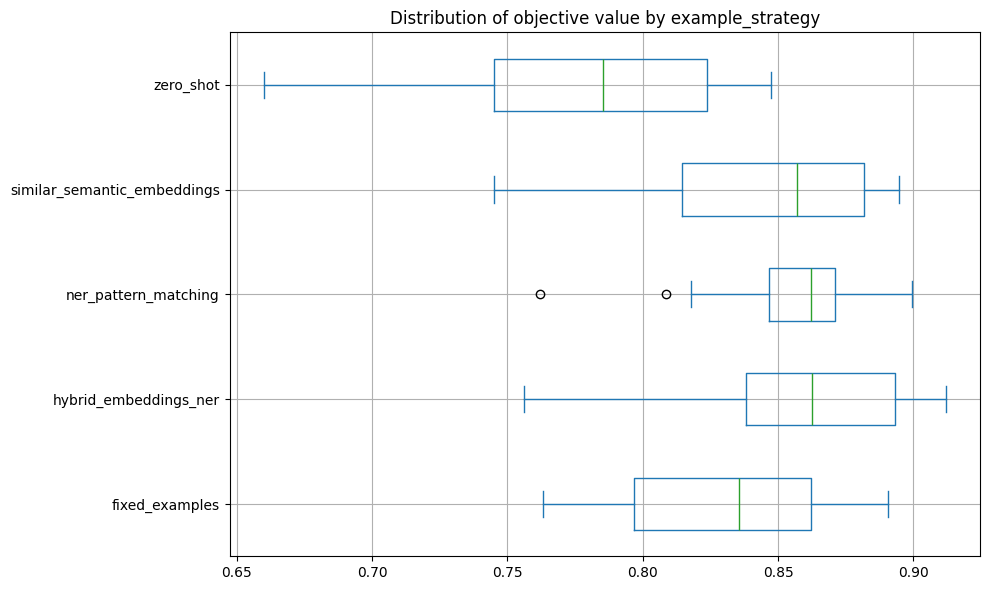

In [20]:
param_box_plot(study_df, param_name="example_strategy").figure.tight_layout()


**Observations:**
- NER pattern matching and hybrid matching seem to perform the best, slightly outperforming embedding similarity

    - NER pattern matching is less stable, likely due to variance from the choice of embedding model. On next studies, embedding model will be fixed.

- Similarity embeddings and fixed examples show similar performance

- Zero shot shows very low performance compared to other strategies, proving once more the examples help.

## Embedding models

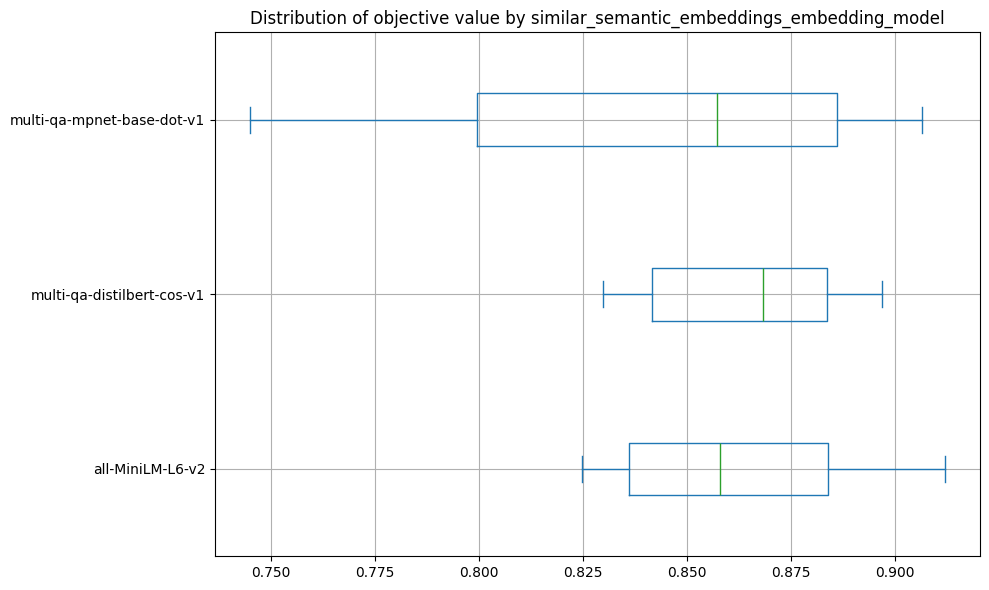

In [21]:
param_box_plot(study_df, param_name="similar_semantic_embeddings_embedding_model").figure.tight_layout()

**Observations**:
- distillbert and MiniLM perform similarly
- mpnet performs significantly worse

## Example limit and threshold

/home/rpatroni/bzk-post-processing/.conda/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


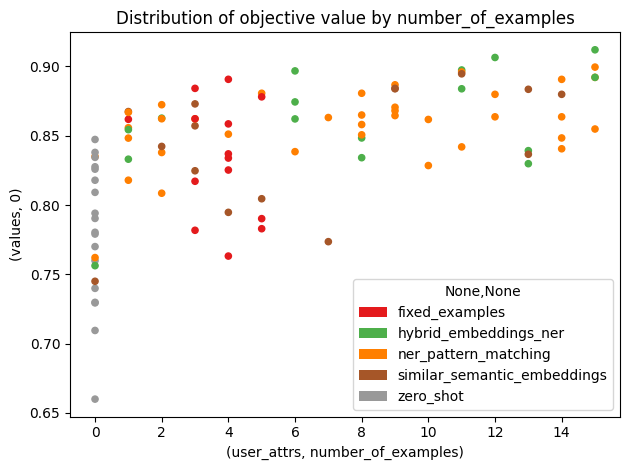

In [30]:
param_scatter_plot(study_df, user_attr="number_of_examples", c=("params", "example_strategy"), colormap="Set1").figure.tight_layout()


**Observations:**
- Fixed examples trend suggests selecting more fixed examples might be worth it
- General trend suggests raising the example maximum may also be worth it
- Very little trials run on similar semantic embeddings with more than 6 examples compared to other strategies. This might reflect that optuna's parameter recommendation algorithm has determined it to be less useful, but it makes comparison less reliable.

/home/rpatroni/bzk-post-processing/.conda/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


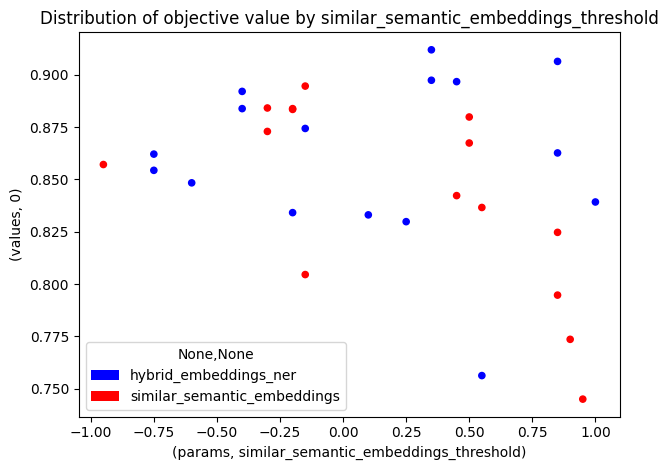

In [ ]:
param_scatter_plot(study_df, param_name="similar_semantic_embeddings_threshold", c=("params", "example_strategy"), colormap="bwr").figure.tight_layout()

**Observations:**
- hybrid matching trend suggests higher performance at higher thresholds. Given that the threshold limits embedding examples only, this suggests NER matching is better.

# Prompt Restrictions

Set of instrunctions given to the model that are intended to restrict its answers.

Example:
```md
## Rules:

- Only extract information **explicitly present in the address**.
- If the address contains a neighborhood joined together with a city by a dash (e.g., Berlin-Marienfelde), separate them accordingly.
- Neighborhoods or boroughs should **not be classified as cities**.
- Do **not infer missing components**.
- Sometimes cities will include (often connected by a slash "/") a reference to a nearby place (eg. river, city, district or region) for the purpose of disambiguation. If this is commonly part of the city name (eg. Frankfurt am Main), include it as part of the city component. Otherwise, it it fits another component type, classify it as such. Finally, if it does not fit any component type include it in the city name anyway.
- Do not extract punctuation around the words such as commas or dashes. The exception is when the word ends in a period to mark it as an abbreviation
- If uncertain about a component type, exclude it from the output.
```

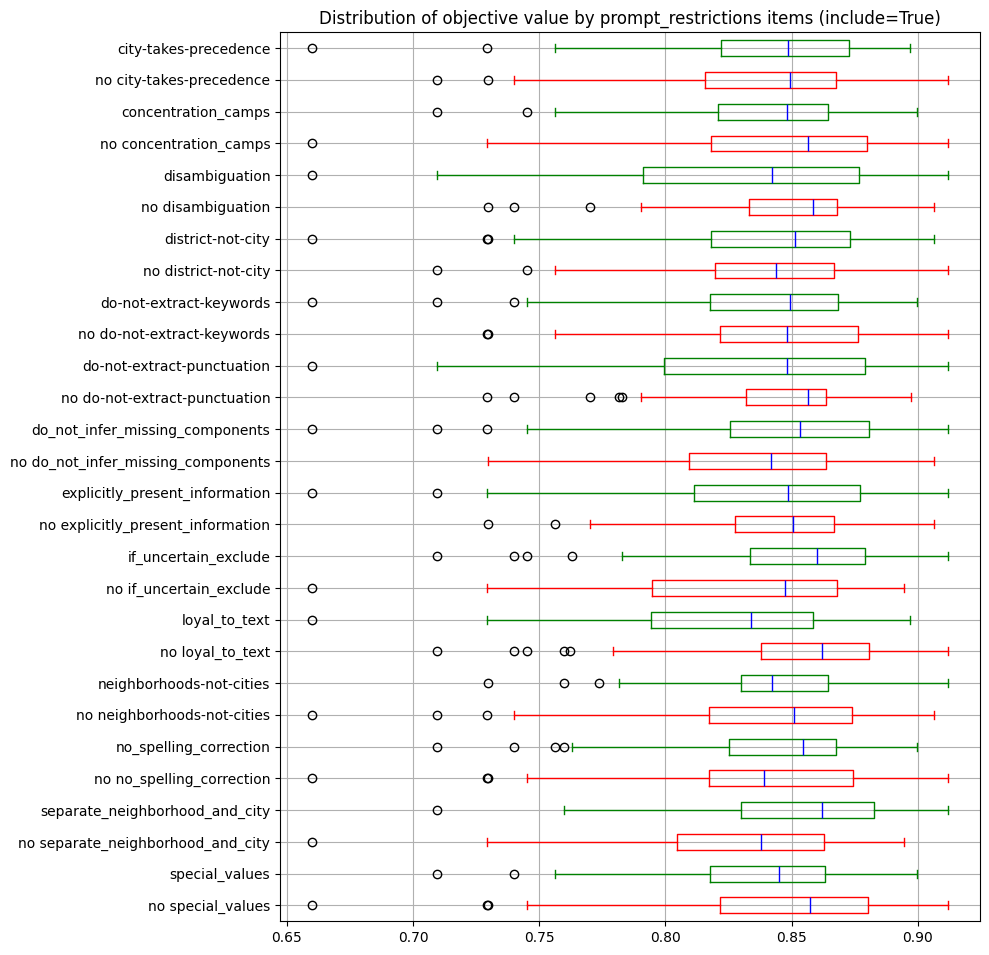

In [ ]:
param_list_box_plot(study_df, list_key="prompt_restrictions").figure.tight_layout()

**Items that seem to have negative impact**:

In [ ]:
show_prompt_items(TASK_RESTRICTIONS, [
    "disambiguation",
    "do-not-extract-keywords",
    "loyal_to_text"
])

disambiguation
  Sometimes cities will include (often connected by a slash "/") a
  reference to a nearby place (eg. river, city, district or region)
  for the purpose of disambiguation. If this is commonly part of the
  city name (eg. Frankfurt am Main), include it as part of the city
  component. Otherwise, it it fits another component type, classify it
  as such. Finally, if it does not fit any component type include it
  in the city name anyway.

do-not-extract-keywords
  Do not extract keywords that identify a component type such as
  "Kreis", "Nr." or "Apt.". The exception is streets and cities, which
  typically include such keywords as part of their name

loyal_to_text
  Remain loyal to the original text.



**Items that seem to have positive impact**:

In [ ]:
show_prompt_items(TASK_RESTRICTIONS, [
    "do_not_infer_missing_components",
    "neighborhoods-not-cities",
    "separate_neighborhood_and_city",
])

do_not_infer_missing_components
  Do **not infer missing components**.

neighborhoods-not-cities
  Neighborhoods or boroughs should **not be classified as cities**.

separate_neighborhood_and_city
  If the address contains a neighborhood joined together with a city
  by a dash (e.g., Berlin-Marienfelde), separate them accordingly.



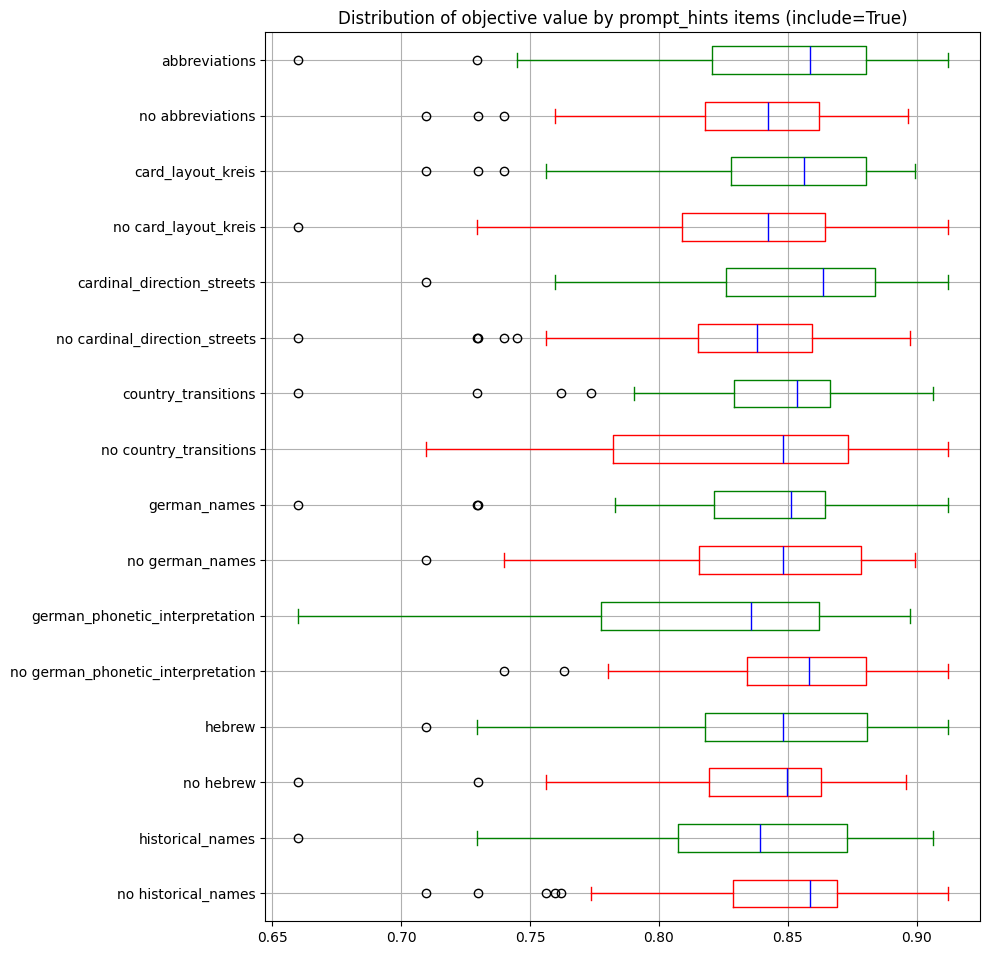

In [ ]:
param_list_box_plot(study_df, list_key="prompt_hints").figure.tight_layout()


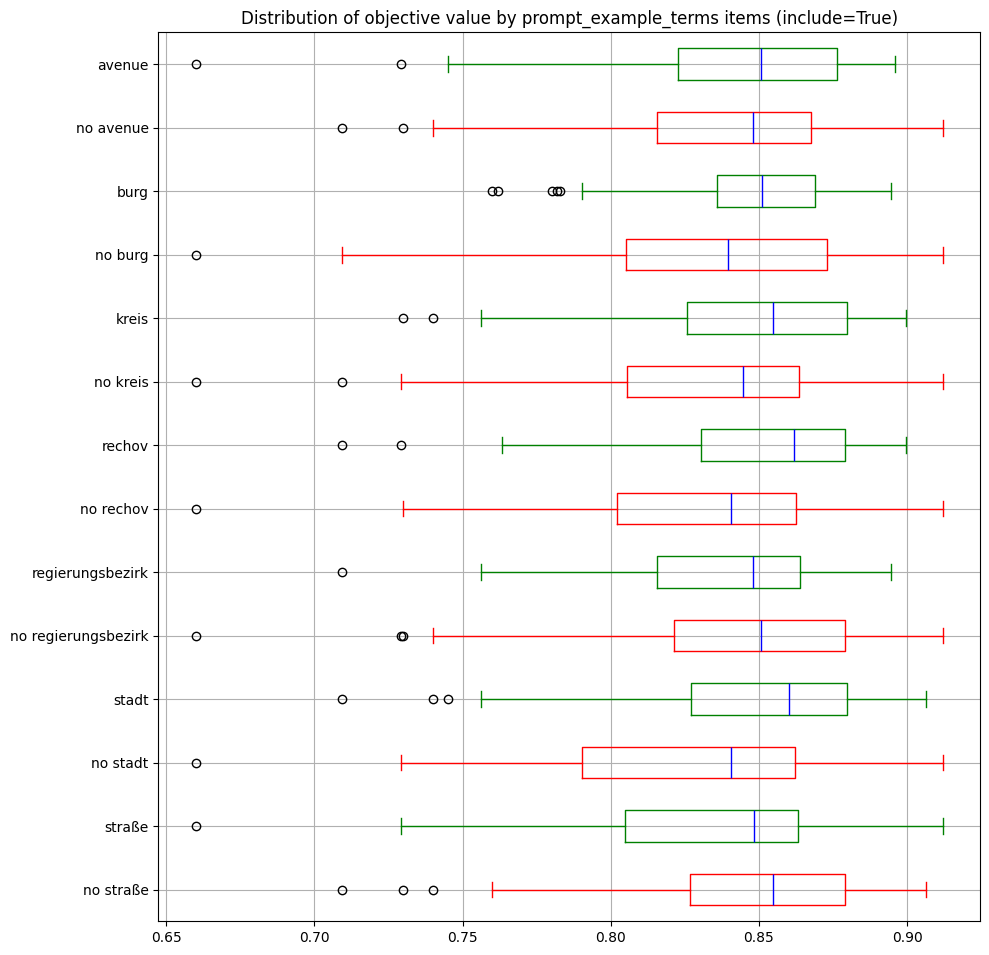

In [ ]:
param_list_box_plot(study_df, list_key="prompt_example_terms").figure.tight_layout()


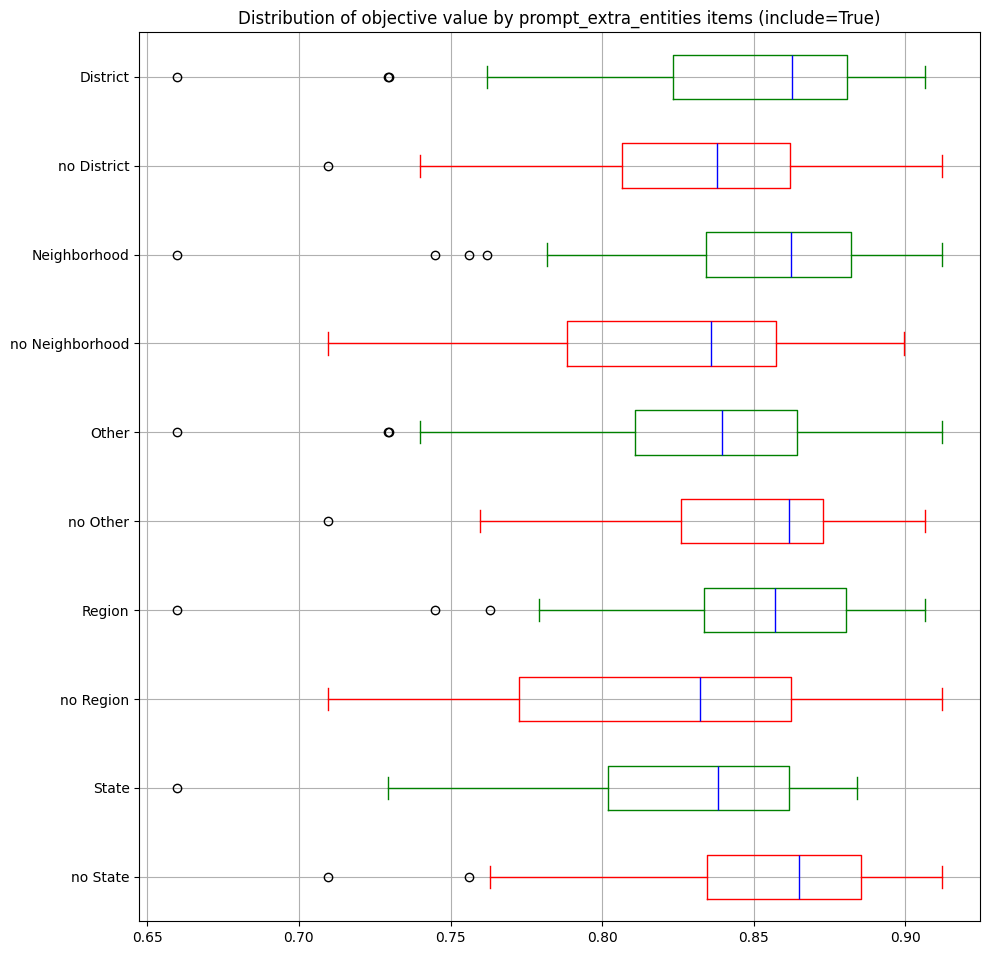

In [ ]:
param_list_box_plot(study_df, list_key="prompt_extra_entities").figure.tight_layout()

Example 0: Frankfurt/Main, Voltastr. 51
             {'HouseNumber': '51', 'StreetName': 'Voltastr.', 'City': 'Frankfurt/Main', 'District': '', 'State': '', 'Country': ''}
Example 1: Frankfurt a.M.
             {'HouseNumber': '', 'StreetName': '', 'City': 'Frankfurt a.M.', 'District': '', 'State': '', 'Country': ''}
Example 2: Weener/Ostfr.
             {'HouseNumber': '', 'StreetName': '', 'City': 'Weener', 'District': '', 'State': '', 'Country': ''}
Example 3: Bergen/Norwegen, Rich. Nordrakagate 4
             {'HouseNumber': '4', 'StreetName': 'Rich. Nordrakagate', 'City': 'Bergen', 'District': '', 'State': '', 'Country': 'Norwegen'}
Example 4: Gräfelfing b.München, Hartnagelstr.1/I
             {'HouseNumber': '1/I', 'StreetName': 'Hartnagelstr.', 'City': 'Gräfelfing', 'District': '', 'State': '', 'Country': ''}
Example 5: Asdod-Iam, Block 1049/8 Israel
             {'HouseNumber': 'Block 1049/8', 'StreetName': '', 'City': 'Asdod-Iam', 'District': '', 'State': '', 'Country': 'Isra

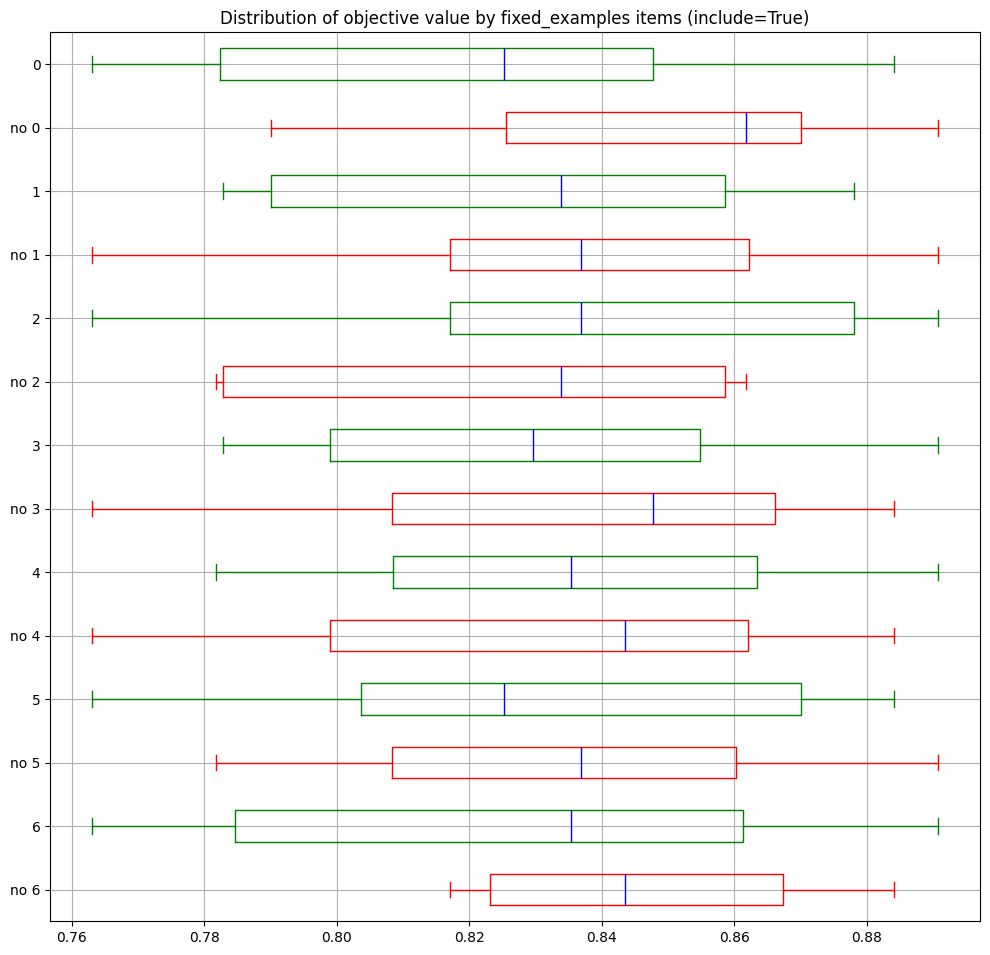

In [ ]:
for i, example in enumerate(FIXED_DEMO_EXAMPLES):
    print(f"Example {i}: {example[0]}")
    print(f"             {example[1]}")
param_list_box_plot(study_df, list_key="fixed_examples").figure.tight_layout()

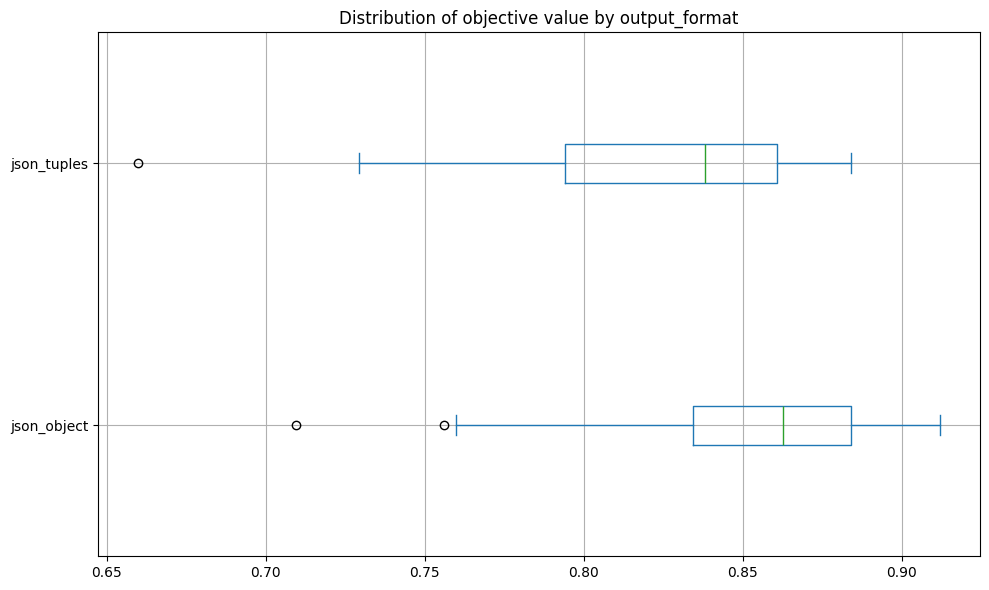

In [ ]:
param_box_plot(study_df, param_name="output_format").figure.tight_layout()

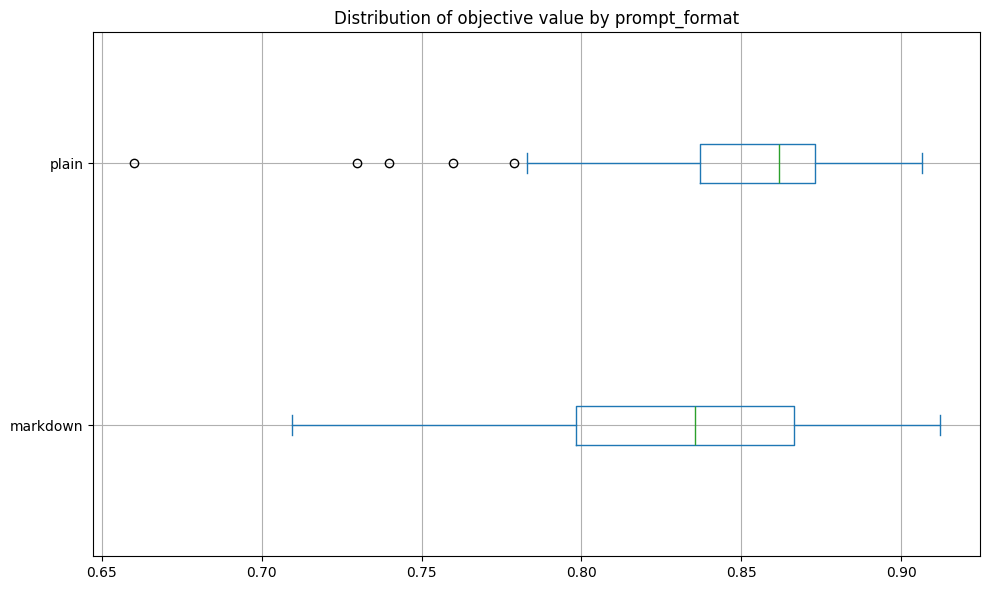

In [ ]:
param_box_plot(study_df, param_name="prompt_format").figure.tight_layout()